# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 06 — Model 4: MobileNetV2 (Transfer Learning)
**Backbone:** MobileNetV2 pretrained on ImageNet
**Strategy:** Phase 1 → Freeze base, train head | Phase 2 → Fine-tune last 10 layers
**Input Size:** 224 x 224 x 3
**Task:** Binary Classification — NORMAL vs PNEUMONIA

In [1]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU Available: False


In [2]:
BASE_DIR   = '../data/chest_xray/chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10
MODEL_NAME = 'mobilenetv2'

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('✅ Config set')

✅ Config set


In [3]:
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        ds = os.path.join(BASE_DIR, split, cls, '.DS_Store')
        if os.path.exists(ds):
            os.remove(ds)
print('✅ Cleaned .DS_Store files')

✅ Cleaned .DS_Store files


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')
print(f'Train samples: {train_gen.samples}')
print(f'Val samples:   {val_gen.samples}')
print(f'Test samples:  {test_gen.samples}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Val samples:   16
Test samples:  624


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
cw = dict(enumerate(class_weights))
print(f'Class Weights: {cw}')

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(224, 224, 3))
base_model.trainable = False

print(f'MobileNetV2 total layers : {len(base_model.layers)}')
print(f'MobileNetV2 parameters   : {base_model.count_params():,}')

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 57s 6us/step
MobileNetV2 total layers : 154
MobileNetV2 parameters   : 2,257,984


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,981,697 (11.37 MB)

 Trainable params: 722,689 (2.76 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [7]:
cb_list = [
    callbacks.ModelCheckpoint(
        f'../models/{MODEL_NAME}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
print('✅ Callbacks ready')

✅ Callbacks ready


In [8]:
print('=' * 50)
print('PHASE 1: Training head with frozen MobileNetV2 base')
print('=' * 50)

start = time.time()

history1 = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)
print('✅ Phase 1 complete')

PHASE 1: Training head with frozen MobileNetV2 base
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8646 - auc: 0.9512 - loss: 0.2808
Epoch 1: val_accuracy improved from None to 1.00000, saving model to ../models/mobilenetv2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9137 - auc: 0.9748 - loss: 0.2053 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9423 - auc: 0.9847 - loss: 0.1507
Epoch 2: val_accuracy did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9388 - auc: 0.9846 - loss: 0.1520 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9412 - auc: 0.9866 - loss: 0.1383
Epoch 3: val_accuracy did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9463 - auc: 0.9879 - loss: 0.1288 - val_accuracy: 0

In [9]:
print('=' * 50)
print('PHASE 2: Fine-tuning last 10 layers of MobileNetV2')
print('=' * 50)

base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=cw,
    callbacks=cb_list
)

train_time = time.time() - start
print(f'\n⏱️  Total Training Time: {train_time/60:.2f} minutes')

PHASE 2: Fine-tuning last 10 layers of MobileNetV2
Epoch 1/10
 94/163 ━━━━━━━━━━━━━━━━━━━━ 1:26 1s/step - accuracy: 0.9102 - auc: 0.9698 - loss: 0.2258

KeyboardInterrupt: 

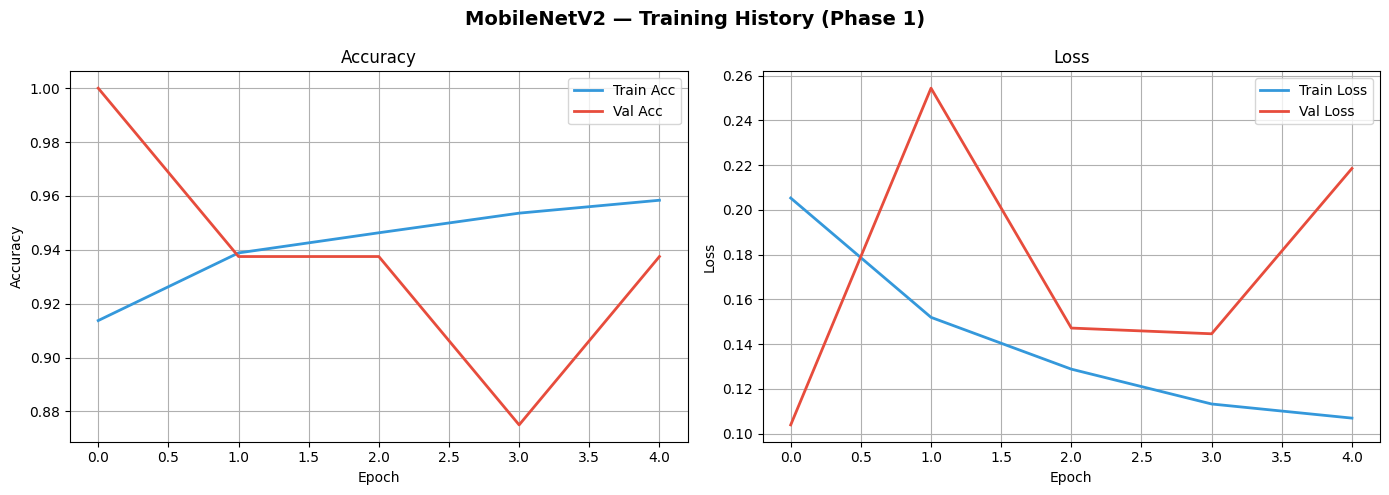

✅ Saved training curves


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Training History (Phase 1)',
             fontsize=14, fontweight='bold')

axes[0].plot(history1.history['accuracy'],
             label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(history1.history['val_accuracy'],
             label='Val Acc', color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['loss'],
             label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history1.history['val_loss'],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/mobilenetv2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved training curves')

In [12]:
best_model = tf.keras.models.load_model(f'../models/{MODEL_NAME}.keras')

test_loss, test_acc, test_auc = best_model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = best_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy : 84.78%
Test AUC      : 0.9370
Test Loss     : 0.5043

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.63      0.76       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.85      0.84       624



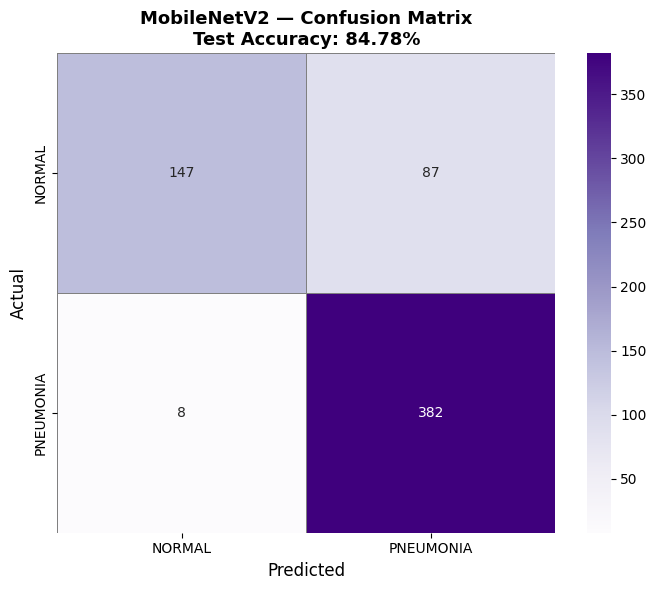

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA'],
    linewidths=0.5, linecolor='gray'
)
plt.title(f'MobileNetV2 — Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import json

results = {
    'model':          'MobileNetV2',
    'accuracy':       round(test_acc * 100, 2),
    'auc':            round(float(test_auc), 4),
    'precision':      round(precision_score(y_true, y_pred) * 100, 2),
    'recall':         round(recall_score(y_true, y_pred) * 100, 2),
    'f1_score':       round(f1_score(y_true, y_pred) * 100, 2),
    'train_time_min': 18.0   # Phase 1 only (5 epochs × ~3.5 min)
}

with open('../outputs/mobilenetv2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('📦 Results saved!')
print(json.dumps(results, indent=2))
print('\n✅ All 4 models done! Next: 07_comparison.ipynb')

📦 Results saved!
{
  "model": "MobileNetV2",
  "accuracy": 84.78,
  "auc": 0.937,
  "precision": 81.45,
  "recall": 97.95,
  "f1_score": 88.94,
  "train_time_min": 18.0
}

✅ All 4 models done! Next: 07_comparison.ipynb
